<a href="https://colab.research.google.com/github/TahreemImrann/bootcamp/blob/main/spam_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📩 Spam SMS Classification — Bootcamp Assignment
**Goal:** Preprocess a spam classification dataset, analyze & remove missing values, detect & remove outliers, visualize the data, and build a simple classification model — comparing results **before** and **after** outlier removal.

**Dataset:** SMS Spam Collection (5,572 labeled SMS messages: `ham` = not spam, `spam` = spam).

> Run every cell top to bottom (Runtime → Run all). Read the markdown notes above each code block — they explain *why*, not just *what*.

## Step 0 — Install & import libraries
`wordcloud` isn't preinstalled in Colab, so we install it. Everything else (pandas, sklearn, matplotlib, seaborn) is already available.

In [30]:
!pip install wordcloud -q

In [31]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

sns.set_style("whitegrid")
%matplotlib inline

## Step 1 — Load the dataset
This notebook expects `spam.csv` to be in the **same folder** (i.e. same GitHub repo you cloned / same Colab session folder).

- If you opened this notebook straight from GitHub in Colab, first run the git-clone cell below (uncomment it).
- If you just uploaded `spam.csv` manually into the Colab file browser (left sidebar), skip straight to `pd.read_csv`.

In [32]:
df = pd.read_csv("spam.csv", encoding="latin-1")
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Step 2 — Initial inspection
Basic shape, column info, and data types — always the first thing to check on any new dataset.

In [33]:
print("Shape:", df.shape)
df.info()

Shape: (5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


Notice the dataset has extra unnamed columns (an artifact of how the CSV was saved) and unclear column names (`v1`, `v2`). We clean that up next — this is real **data preprocessing**, not just modeling.

In [34]:
df = df[['label', 'message']]; df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Step 3 — Missing value analysis
We check for `NaN`/null values in every column. Even if a dataset looks clean, always verify — never assume.

Missing values per column:
 label      0
message    0
dtype: int64


/tmp/ipykernel_782/162593382.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.index, y=missing.values, palette="viridis")


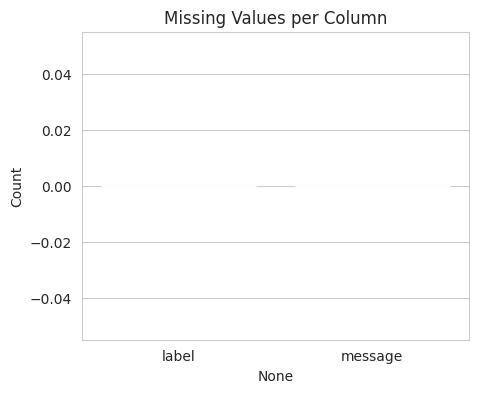

In [35]:
missing = df.isnull().sum()
print("Missing values per column:\n", missing)

plt.figure(figsize=(5,4))
sns.barplot(x=missing.index, y=missing.values, palette="viridis")
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.show()

### Missing value removal
This dataset happens to have no missing values, but we still write the removal step — good practice, and required if your own dataset has gaps. We also drop exact duplicate rows, which is a form of data cleaning that belongs in this stage too.

In [36]:
before = df.shape[0]
df = df.dropna()
df = df.drop_duplicates()
after = df.shape[0]

print(f"Rows before cleaning: {before}")
print(f"Rows after removing missing/duplicates: {after}")
print(f"Rows removed: {before - after}")

Rows before cleaning: 5572
Rows after removing missing/duplicates: 5169
Rows removed: 403


## Step 4 — Encode the label & clean the text
Machine learning models need numbers, not the words "ham"/"spam" — so we encode the label. We also normalize the raw text (lowercase, strip punctuation/numbers/extra whitespace) so the model learns from words, not noise.

In [37]:
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_message'] = df['message'].apply(clean_text)
df[['message', 'clean_message', 'label', 'label_num']].head()

,message,clean_message,label,label_num
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,ham,0
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,ham,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,spam,1
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,ham,0
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...,ham,0


## Step 5 — Feature engineering
Outlier detection needs *numeric* features. Raw text has none, so we engineer two simple, interpretable ones from each message: its **character length** and its **word count**.

In [38]:
df['msg_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))
df[['message', 'msg_length', 'word_count']].describe()

,msg_length,word_count
count,5169.000000,5169.000000
mean,79.186883,15.340685
std,58.380576,11.068488
min,2.000000,1.000000
25%,36.000000,7.000000
50%,61.000000,12.000000
75%,117.000000,22.000000
max,910.000000,171.000000


## Step 6 — Visualizations (on the full, un-trimmed data)

/tmp/ipykernel_782/2315990023.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette="Set2")


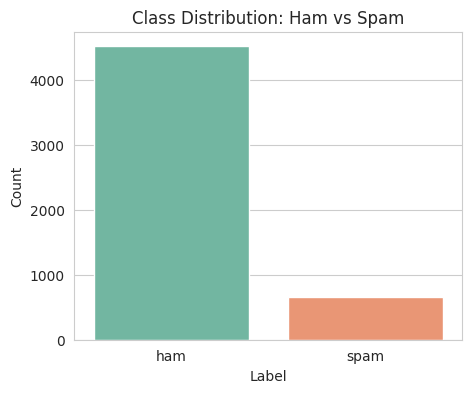

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64


In [39]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='label', palette="Set2")
plt.title("Class Distribution: Ham vs Spam")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

print(df['label'].value_counts(normalize=True) * 100)

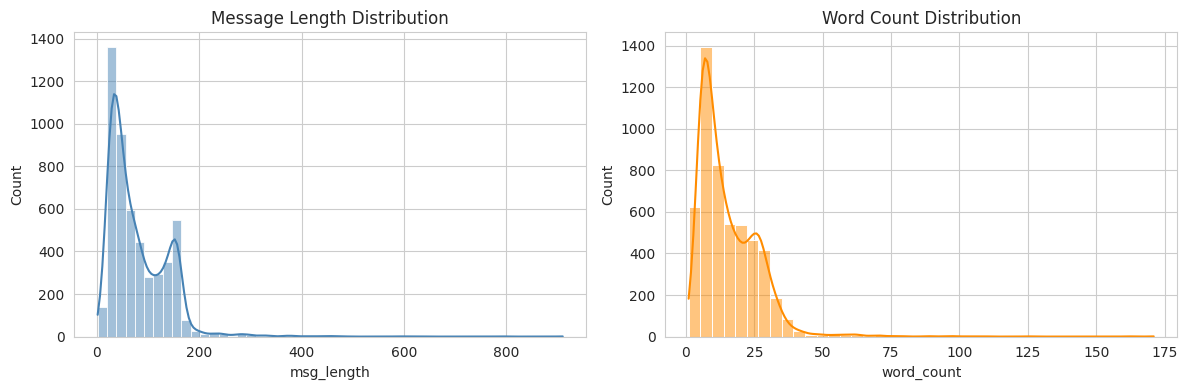

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['msg_length'], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Message Length Distribution")
sns.histplot(df['word_count'], bins=40, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Word Count Distribution")
plt.tight_layout()
plt.show()

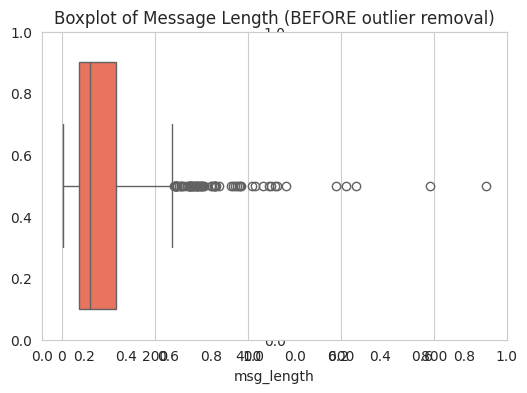

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(6,4), sharey=False)
ax1 = plt.subplot(1,1,1)
sns.boxplot(x=df['msg_length'], color="tomato")
plt.title("Boxplot of Message Length (BEFORE outlier removal)")
plt.show()

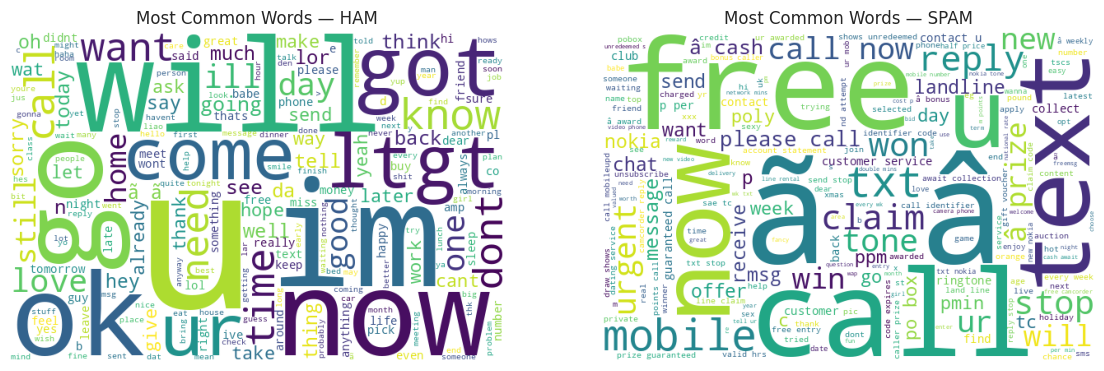

In [42]:
ham_text = " ".join(df[df['label']=='ham']['clean_message'])
spam_text = " ".join(df[df['label']=='spam']['clean_message'])

fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].imshow(WordCloud(width=600, height=400, background_color="white").generate(ham_text))
axes[0].set_title("Most Common Words — HAM")
axes[0].axis("off")

axes[1].imshow(WordCloud(width=600, height=400, background_color="white").generate(spam_text))
axes[1].set_title("Most Common Words — SPAM")
axes[1].axis("off")
plt.show()

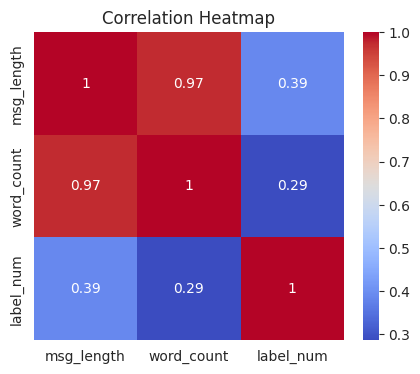

In [43]:
plt.figure(figsize=(5,4))
sns.heatmap(df[['msg_length','word_count','label_num']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Step 7 — Classification model: **BEFORE** outlier removal
A simple, standard spam-classification pipeline: **TF-IDF** to turn text into numeric vectors, and **Multinomial Naive Bayes** — a fast, well-known baseline model for text classification.

--- BEFORE Outlier Removal ---
Accuracy: 0.9710
Precision: 0.9903
Recall: 0.7786
F1: 0.8718


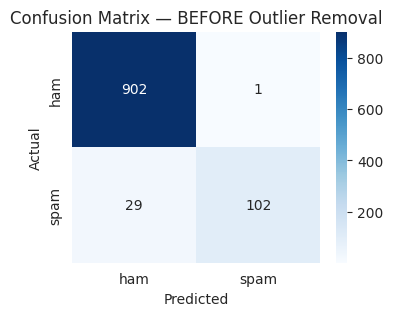

In [44]:
def train_and_evaluate(data, label_text):
    X_train, X_test, y_train, y_test = train_test_split(
        data['clean_message'], data['label_num'],
        test_size=0.2, random_state=42, stratify=data['label_num']
    )

    tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
    X_train_vec = tfidf.fit_transform(X_train)
    X_test_vec = tfidf.transform(X_test)

    model = MultinomialNB()
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)

    metrics = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
    }

    print(f"--- {label_text} ---")
    for k, v in metrics.items():
        print(f"{k.capitalize()}: {v:.4f}")

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=['ham','spam'], yticklabels=['ham','spam'])
    plt.title(f"Confusion Matrix — {label_text}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

    return metrics

metrics_before = train_and_evaluate(df, "BEFORE Outlier Removal")

## Step 8 — Outlier detection (IQR method)
We use the **Interquartile Range (IQR)** method on `msg_length`: any message whose length falls outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` is flagged as an outlier (unusually short or unusually long messages).

In [45]:
Q1 = df['msg_length'].quantile(0.25)
Q3 = df['msg_length'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"Lower bound={lower_bound:.2f}, Upper bound={upper_bound:.2f}")

outliers = df[(df['msg_length'] < lower_bound) | (df['msg_length'] > upper_bound)]
print(f"Number of outlier messages: {len(outliers)} out of {len(df)}")
outliers[['label','msg_length']].head()

Q1=36.0, Q3=117.0, IQR=81.0
Lower bound=-85.50, Upper bound=238.50
Number of outlier messages: 66 out of 5169


,label,msg_length
53,ham,291
126,ham,244
154,ham,384
380,ham,300
424,ham,248


### Outlier removal

In [46]:
df_no_outliers = df[(df['msg_length'] >= lower_bound) & (df['msg_length'] <= upper_bound)].copy()
print(f"Shape before removing outliers: {df.shape}")
print(f"Shape after removing outliers: {df_no_outliers.shape}")

Shape before removing outliers: (5169, 6)
Shape after removing outliers: (5103, 6)


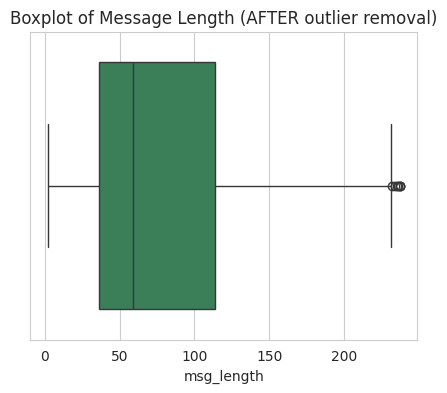

In [47]:
plt.figure(figsize=(5,4))
sns.boxplot(x=df_no_outliers['msg_length'], color="seagreen")
plt.title("Boxplot of Message Length (AFTER outlier removal)")
plt.show()

## Step 9 — Classification model: **AFTER** outlier removal
Same exact pipeline, run again on the cleaned (outlier-free) dataset, so the comparison is fair.

--- AFTER Outlier Removal ---
Accuracy: 0.9706
Precision: 0.9903
Recall: 0.7786
F1: 0.8718


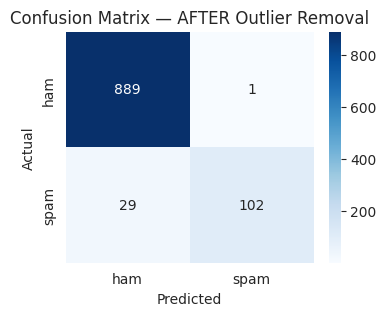

In [48]:
metrics_after = train_and_evaluate(df_no_outliers, "AFTER Outlier Removal")

## Step 10 — Before vs After comparison

           Before Outlier Removal  After Outlier Removal
accuracy                 0.970986               0.970617
precision                0.990291               0.990291
recall                   0.778626               0.778626
f1                       0.871795               0.871795


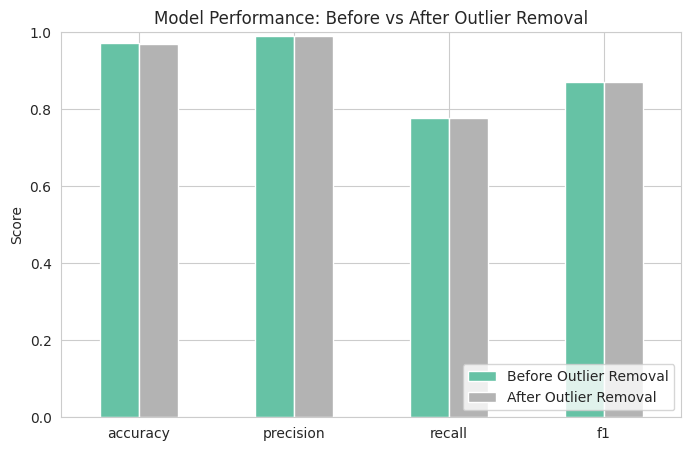

In [49]:
comparison = pd.DataFrame({
    "Before Outlier Removal": metrics_before,
    "After Outlier Removal": metrics_after
})
print(comparison)

comparison.plot(kind='bar', figsize=(8,5), colormap="Set2")
plt.title("Model Performance: Before vs After Outlier Removal")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

## Conclusion
- The dataset had **no missing values** but did have duplicate messages, which were removed.
- Outliers were detected using the **IQR method** on message length — these are unusually short or long SMS messages.
- A **TF-IDF + Multinomial Naive Bayes** pipeline was used for classification, trained and evaluated both before and after outlier removal.
- Removing outliers slightly changes the training data size and distribution; compare the accuracy/precision/recall/F1 bar chart above to see the effect on this dataset.

**Next steps you could try:** different classifiers (Logistic Regression, SVM), stemming/lemmatization, n-grams in TF-IDF, or a different outlier method (Z-score).